# Project: Neutrino Portal at the Muon Collider

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import pathlib
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
from scipy.stats import gaussian_kde

In [2]:
#load ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier



## Define Signals and background

**Added "CC_numu_displaced","CC_nuebar_displaced","NC_numu_displaced","NC_nuebar_displaced" in dataset_bg**

In [3]:
datasets_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar","CC_numu_displaced","CC_nuebar_displaced","NC_numu_displaced","NC_nuebar_displaced"]
#datasets_bg = ["CC_numu_displaced","CC_nuebar_displaced","NC_numu_displaced","NC_nuebar_displaced"]


datasets_sig = ["0.001GeV","0.01GeV","0.05GeV", "0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV",
    "16GeV","17.5GeV","18GeV","19.95GeV","21GeV","23GeV","25GeV","30GeV","40GeV"]

## Load all events 



Explanation for file format of MC_-14_3TeV_with_cut_with_final.txt: The first column in the file is energy in GeV. The second column is the flux of $\nu_{\mu}$ per year. The third column is the flux of $\bar\nu_{e}$ per year. The remaining columns are for cross sections of the different charged and neutral current processes for $\nu_{\mu}$ and $\bar\nu_{e}$ in units of $cm^{2}$. The cross sections have been obtained using pythia.SigmaGen() and compared with cross-section produced by GENIE. The last two columns correspond to cross section at $\lambda_{\mu\mu}$=1 for the two signals at mass 125MeV and 20 GeV. The cross section has been obtained using MADGRAPH. For the two signals, the flux of incoming neutrinos is considered to be that of $\nu_{\mu}$ as it is the source from which signals originate.

To get the event weight, we divide the number of interacting neutrinos per year by the number of monte carlo events generated to normalize it. 
\begin{equation}
N{\nu}_{\mu} =\frac{\sigma\times\rho\times l_{det}\times N_{inc}}{m_{p}} 
\end{equation}

Here, $\sigma\times10^{-36}$ is the cross section in $cm^{2}$, $\rho$ is the density of iron in $g/cm^{3}$, $l_{det}$ is the length of detector in centimeters, $N_{inc}$ is the number of incident neutrinos per year and $m_p$ is the mass of proton in gram. 


***The weight of the event is kept 1 for prompt background and signal while the weight of the displaced events are kept as the decay probability of pion/kaon. To get the number of events in the detector, the weight of events is multiplied by number of interacting neutrinos. So, instead of  observables(weight) = weight I replace it with  observables (weight) *= weight. I use the same flux  and cross section of neutrinos for CC and NC displaced events as for the prompt events. ***

In [4]:
def load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final_output_modified_all_mass.txt'):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g
    l_det = 4.0425         # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2 

    #initialize output 
    all_data = None
    
    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 
    scaling_data['energy'] = round(scaling_data['energy'],0)
    
    #loop over datasets 
    #datasets_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar"]
    #datasets_sig = ["0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","19.95GeV"]
    datasets = datasets_bg + datasets_sig
    for dataset in datasets:
        
        # get all files and loop over them
        dirname = 'output_events_' + dataset  
        directory = pathlib.Path(dirname)
        
        
        # Check if dataset starts with a number
        try:
            float(dataset.replace("GeV", ""))  # Remove "GeV" and check if it's a number
            is_number = True
        except ValueError:
            is_number = False

        if is_number:
            files = sorted(directory.rglob('observables_new*.csv.zip'))
        else:
            files = sorted(directory.rglob('observables_new*.csv.zip'))
            
            
        #import data on generated event rates
        generated_data_name = dirname+"/generated_events.json"
        with open(generated_data_name, "r") as f: generated_data_raw = json.load(f)
        generated_data = {int(float(key)): value for key, value in generated_data_raw.items()}

        for file in files:
            
            # get beam energy
            energy = float(str(file).split('_')[-1].replace('.csv.zip', ''))
                
            # load data, get observables
            observables = pd.read_csv(str(file))
            observables['set'] = dataset
            print("load file: "+ str(file), len(observables))
            
            # obtain number of events (allows for different nevents for different energies)
            nevent = generated_data[int(energy)]
            
            # calculate scaling factor            
            scaling_row = scaling_data[scaling_data['energy'] == round(energy,0)]
            base_dataset = "_".join(dataset.split("_")[:2])
            cross_section = scaling_row[base_dataset].values[0]
            
            if dataset in datasets_sig: flux = scaling_row["numu"+"_flux"].values[0]
            else: flux = scaling_row[dataset.split("_")[1] + "_flux" ].values[0] 
            weightt = ((cross_section * flux * mul)/nevent)    
            if dataset in datasets_sig:
                observables['weight'] *= weightt
                
            else:
                observables['weight'] *= weightt
                
            # combine data
            if all_data is None: all_data = observables
            else:all_data = pd.concat([all_data, observables])
    
    return all_data.reset_index(drop=True)

- load all events

In [5]:
data0 = load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final_output_modified_all_mass.txt')

load file: output_events_CC_numu/observables_new_112.94.csv.zip 302398
load file: output_events_CC_numu/observables_new_1129.46.csv.zip 666060
load file: output_events_CC_numu/observables_new_14.21.csv.zip 59683
load file: output_events_CC_numu/observables_new_142.19.csv.zip 313476
load file: output_events_CC_numu/observables_new_1421.9.csv.zip 682495
load file: output_events_CC_numu/observables_new_17.9.csv.zip 66597
load file: output_events_CC_numu/observables_new_179.0.csv.zip 323524
load file: output_events_CC_numu/observables_new_22.53.csv.zip 73040
load file: output_events_CC_numu/observables_new_225.35.csv.zip 332732
load file: output_events_CC_numu/observables_new_28.37.csv.zip 77424
load file: output_events_CC_numu/observables_new_283.7.csv.zip 342260
load file: output_events_CC_numu/observables_new_35.71.csv.zip 82520
load file: output_events_CC_numu/observables_new_357.16.csv.zip 351243
load file: output_events_CC_numu/observables_new_44.964.csv.zip 87501
load file: output_e

load file: output_events_CC_nuebar_displaced/observables_new_28.37.csv.zip 0
load file: output_events_CC_nuebar_displaced/observables_new_283.7.csv.zip 2470
load file: output_events_CC_nuebar_displaced/observables_new_35.71.csv.zip 0
load file: output_events_CC_nuebar_displaced/observables_new_357.16.csv.zip 3604
load file: output_events_CC_nuebar_displaced/observables_new_44.964.csv.zip 1
load file: output_events_CC_nuebar_displaced/observables_new_449.64.csv.zip 4864
load file: output_events_CC_nuebar_displaced/observables_new_56.6.csv.zip 16
load file: output_events_CC_nuebar_displaced/observables_new_566.07.csv.zip 6474
load file: output_events_CC_nuebar_displaced/observables_new_71.26.csv.zip 55
load file: output_events_CC_nuebar_displaced/observables_new_712.64.csv.zip 8111
load file: output_events_CC_nuebar_displaced/observables_new_89.71.csv.zip 171
load file: output_events_CC_nuebar_displaced/observables_new_897.16.csv.zip 10075
load file: output_events_NC_numu_displaced/obser

load file: output_events_0.05GeV/observables_new_56.6.csv.zip 9966
load file: output_events_0.05GeV/observables_new_566.07.csv.zip 10000
load file: output_events_0.05GeV/observables_new_71.26.csv.zip 9982
load file: output_events_0.05GeV/observables_new_712.64.csv.zip 10000
load file: output_events_0.05GeV/observables_new_89.71.csv.zip 9993
load file: output_events_0.05GeV/observables_new_897.16.csv.zip 10000
load file: output_events_0.125GeV/observables_new_112.94.csv.zip 9997
load file: output_events_0.125GeV/observables_new_1129.46.csv.zip 10000
load file: output_events_0.125GeV/observables_new_14.21.csv.zip 683
load file: output_events_0.125GeV/observables_new_142.19.csv.zip 9998
load file: output_events_0.125GeV/observables_new_1421.9.csv.zip 10000
load file: output_events_0.125GeV/observables_new_17.9.csv.zip 6229
load file: output_events_0.125GeV/observables_new_179.0.csv.zip 9999
load file: output_events_0.125GeV/observables_new_22.53.csv.zip 8668
load file: output_events_0.125

load file: output_events_16GeV/observables_new_897.16.csv.zip 10000
load file: output_events_17.5GeV/observables_new_1129.46.csv.zip 10000
load file: output_events_17.5GeV/observables_new_1421.9.csv.zip 10000
load file: output_events_17.5GeV/observables_new_225.35.csv.zip 0
load file: output_events_17.5GeV/observables_new_283.7.csv.zip 9351
load file: output_events_17.5GeV/observables_new_357.16.csv.zip 9960
load file: output_events_17.5GeV/observables_new_449.64.csv.zip 9989
load file: output_events_17.5GeV/observables_new_566.07.csv.zip 9999
load file: output_events_17.5GeV/observables_new_712.64.csv.zip 9999
load file: output_events_17.5GeV/observables_new_897.16.csv.zip 10000
load file: output_events_18GeV/observables_new_1129.46.csv.zip 10000
load file: output_events_18GeV/observables_new_1421.9.csv.zip 10000
load file: output_events_18GeV/observables_new_225.35.csv.zip 0
load file: output_events_18GeV/observables_new_283.7.csv.zip 8792
load file: output_events_18GeV/observables_n

## Functions

In [6]:
def get_rates(data, header=None, big_det=False, do_print=True):

    if header is not None: print(header + ":")        
    if big_det: factor=1000
    else: factor=1

    # Initialize counters for the combined total
    rates, total_bg, total_bg_mc = {}, 0, 0
    
    # processes
    datasets_sig_show = ["0.001GeV","0.01GeV", "0.125GeV","1GeV","7.94GeV","19.95GeV", "30GeV"]
    
    # background
    for dataset in datasets_bg:
        n_real, n_mc = sum(data[data['set']==dataset]['weight'])*factor, len(data[data['set']==dataset])
        total_bg, total_bg_mc = total_bg+n_real, total_bg_mc+n_mc
        rates[dataset] = [n_real, n_mc]
        if do_print: print ("   "+dataset+": " + str(round(rates[dataset][0],3))+ " (N_MC = "+str(rates[dataset][1])+")") 
    rates['bg'] = [total_bg, total_bg_mc, 0]
    if do_print: print("   Total Background: "+ str(round(total_bg,3))+ " (N_MC = "+str(total_bg_mc)+")")
    
    # threshold signal 
    signal_threshold = max(3,2 * (total_bg**0.5) ) 
    
    # signal
    for dataset in datasets_sig:
        n_real, n_mc = sum(data[data['set']==dataset]['weight'])*factor, len(data[data['set']==dataset])
        coupling = np.sqrt(signal_threshold/n_real)
        rates[dataset] = [n_real, n_mc, coupling]
        if do_print and dataset in datasets_sig_show: 
            print ("   "+dataset+": " + str(round(n_real,3))+ " (N_MC = "+str(n_mc)+"): g>"+str(round(coupling,6))) 

    return rates 


In [7]:
def baseline_plot_big():
    
    # setup figure
    matplotlib.rcParams.update({'font.size': 15})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(7,5))
    
    # future
    future = {
        'DUNE': ['DUNE', 3.5e-1, 2e-2, 0, 'dodgerblue', 'dashed'], 
        'hnunuphi': [r"HL-LHC: $h\rightarrow\nu\nu\phi$", 3e-2, 2.5e-1, 0, 'royalblue', 'dashed'],   
        '100tonne_FLARE': ['   FLARE\n(100 ton)', 2e0, 5.5e-2, 0, 'blue', 'dashed'],   
        'IceCube_Gen-2': ["IC Gen-2", 7e-3, 3e-4, 0, 'deepskyblue', 'dashed'],   
        #'Sebastian_talk_3': ["", 7e-2, 1.6e-4, 0, 'midnightblue', 'dashed'],           
    }
    zorder=-100
    for bound in future.keys():
        label, x, y, rot, col, ls = future[bound]
        data = np.loadtxt('lines/'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color=col, ls=ls, zorder=zorder)
        plt.text(x, y, label, fontsize=13, color=col, rotation=rot)
        zorder+=1
        
    # datasets
    constraints = {
        'BBN_muoncol': ['BBN', 1.5e-3, 1.3e-4, 0],
        #'0v2b': [r'0$\nu$2$\beta$', 2.3e-3, 1e-3, 0],
        'mlnuphi': [r'$M^{\pm}\rightarrow \mu\nu\phi$', 4e-3, 1e-2, 0],
        'Zinv': [r"$Z\rightarrow inv$", 0.7, 6e-1, 0],
        'CMB': ['CMB', 15e-3, 3e-1, 40],
    }
    for bound in constraints.keys():
        label, x, y, rot = constraints[bound]
        data = np.loadtxt('lines/'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color="dimgray", ls='solid', zorder=zorder)
        plt.fill(data.T[0], data.T[1], color="gainsboro", zorder=zorder)
        plt.text(x, y, label, fontsize=14, color='dimgray', rotation=rot)
        zorder+=1
        
    # plot H>inv
    data = np.loadtxt('lines/hinv_mc3.txt')
    plt.plot(data.T[0], data.T[1], color="darkorange", ls='dashdot', zorder=10,lw=2, label=r'Precision $h \to inv$')
        
      
    # datasets
    targets = {
        'Target_CS_DM': ['Complex Scalar', 1.5e-3, 1.3e-4, 0,'dotted'],
        'Target_DF_DM': ['Dirac Fermion', 2.3e-3, 1e-3, 0,'dashdot'],
        #'Dark_matter_target': ['???', 4e-3, 1e-2, 0,'dashed'],
        'Target_SterileNeutrino': [r"Sterile $\nu$", 0.7, 6e-1, 0,(5, (10, 3))],
    }
    for bound in targets.keys():
        label, x, y, rot, ls = targets[bound]
        data = np.loadtxt('lines/'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color='k', ls=ls,lw=2)
        #plt.text(x, y, label, fontsize=13, color='k', rotation=rot)
        
    # finalize
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1e-3, 1e2)
    plt.ylim(1e-4, 1e0)
    plt.xlabel(r'mass $m_\phi$ [GeV]')
    plt.ylabel(r'coupling $\lambda_{\mu\mu}$')
    return plt, fig

In [8]:
def baseline_plot():
    
    # setup figure
    matplotlib.rcParams.update({'font.size': 15})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(7,5))
        
    # datasets
    constraints = {
        'BBN': ['BBN', 1.5e-3, 1.1e-3, 0],
        #'0v2b': [r'0$\nu$2$\beta$', 2.3e-3, 1.1e-3, 0],
        'NA62': ['  NA62\n'+r'$K^{\pm}\rightarrow \mu\nu\phi$', 5e-2, 1e-1, 0],
        'PIENU': ['  PIENU\n'+r'$\pi^{\pm}\rightarrow \mu\nu\phi$', 0.6e-2, 4e-2, 0],
        'Zdecay': [r"LEP $Z\rightarrow \nu\nu\phi$ ", 0.7, 6e-1, 0],
        'CMB': ['CMB', 15e-3, 3e-1, 49],
    }
    zorder=-100
    for bound in constraints.keys():
        label, x, y, rot = constraints[bound]
        data = np.loadtxt('lines/Bound_'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color="dimgray", ls='solid', zorder=zorder)
        plt.fill(data.T[0], data.T[1], color="gainsboro", zorder=zorder)
        plt.text(x, y, label, fontsize=14, color='dimgray', rotation=rot)
        zorder+=1
        
    # finalize
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1e-3, 1e2)
    plt.ylim(1e-3, 1e0)
    plt.xlabel(r'mass $m_\phi$ [GeV]')
    plt.ylabel(r'coupling $\lambda_{\mu\mu}$')
    return plt, fig

In [9]:
def plot_reach(results, big_det=False, order=None,ncol=2, plot_y1=False):
    
    # figure 
    if big_det: plt, fig = baseline_plot_big(plot_y1=plot_y1)
    else: plt, fig = baseline_plot()
    
    # signals 
    masses = [float(m[:-3]) for m in datasets_sig]
    
    # add 
    if order==None: order=results.keys()
    for scenario in order:
        color, label  = results[scenario]['color'], results[scenario]['label']
        numbers, ls = results[scenario]['numbers'], results[scenario]['ls']
        couplings = [numbers[m][2] for m in datasets_sig]
        plt.plot(masses, couplings, label=label, color=color, zorder=10, ls=ls,lw=2)
        
    # legend
    plt.legend(frameon=True, labelspacing=0, loc='lower right', fontsize=14, 
        ncol=ncol, bbox_to_anchor=(1.01,-0.01))
    
    #finalize
    plt.subplots_adjust(left=0.13, right=0.96, bottom=0.12, top=0.975)
    if big_det: fig.savefig('figures/Reach_Big.pdf')
    else:  fig.savefig('figures/Reach.pdf')
    plt.show()

In [10]:
def get_nocut_sensitivity(scaling_file='MC_-14_3TeV_with_cut_with_final_output_modified_all_mass.txt', big_det=False,):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g
    l_det = 4.0425  # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2 
    if big_det: factor=1000
    else: factor=1

    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 
    rates = {} 
    
    #loop over datasets 
    #datasets_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar"]
    total_bg = 0
    for dataset in datasets_bg:
        #fluxtag = dataset[3:]+"_flux"
        fluxtag = dataset.split("_")[1] + "_flux"
        scaling_data['total_'+dataset] = scaling_data["_".join(dataset.split("_")[:2])] * scaling_data[fluxtag] * mul * factor
        total_rate = sum(scaling_data['total_'+dataset])
        rates[dataset] = [total_rate,0,0]
        total_bg += total_rate
        print ("   "+dataset+": " + str(round(total_rate,3))) 
    rates['bg'] = [total_bg, 0, 0]
        
    signal_threshold = max(3,2 * (total_bg**0.5) ) 
    #datasets_sig = ["0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","19.95GeV"]
    for dataset in datasets_sig:
        scaling_data['total_'+dataset] = scaling_data[dataset] * scaling_data["numu_flux"] * mul * factor
        total_rate = sum(scaling_data['total_'+dataset])
        coupling = np.sqrt(signal_threshold/total_rate)    
        rates[dataset] = [total_rate,0,coupling]
            
    return rates

In [11]:
def get_ideal_sensitivity(scaling_file='MC_-14_3TeV_with_cut_with_final_output_modified_all_mass.txt',big_det=False):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g
    l_det = 4.0425         # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2 
    if big_det: factor=1000
    else: factor=1

    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 

    #loop over datasets 
    rates = {} 
    #datasets_sig = ["0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","19.95GeV"]
    for dataset in datasets_sig:
        
        scaling_data['total_'+dataset] = scaling_data[dataset] * scaling_data["numu_flux"] * mul *factor
        total_rate = sum(scaling_data['total_'+dataset])
        coupling = np.sqrt(3./total_rate)    
        rates[dataset] = [total_rate,0,coupling]
            
    return rates

In [12]:
def plot_2d(
        data0,
        data1,
        varx='e_mu_plus',
        vary='e_visible',
        binsx = [1,4,30],
        binsy = [1,4,30],
        label0 = 'Background',
        label1 = 'Signal',
        coupling = 1,
        lines=[],
        logx=True,
        logy=True,
        labelx=None,
        labely=None,
        coupling0=1,
        coupling1=1,
        zlims=[None,None],
        ylabelpad=None,
    ):
   
    #labels
    if labelx == None: labelx=varx
    if labely == None: labely=vary
        
    # remove 0s
    data0 = data0[(data0[varx]>0) & (data0[vary]>0) ].copy()
    data1 = data1[(data1[varx]>0) & (data1[vary]>0) ].copy()
       
    # log ticks and edges
    ticks = np.array([[np.linspace(10**(j),10**(j+1),9)] for j in range(-7,6)]).flatten()
    ticks = [np.log10(x) for x in ticks]
    ticklabels = np.array([[r"$10^{"+str(j)+"}$","","","","","","","",""] for j in range(-7,6)]).flatten()
    
    xmin, xmax, xnum = binsx[0], binsx[1], binsx[2]+1
    ymin, ymax, ynum = binsy[0], binsy[1], binsy[2]+1
    x_edges = np.linspace(xmin, xmax, num=xnum+1)
    y_edges = np.linspace(ymin, ymax, num=ynum+1)
    x_centers = 0.5*(x_edges[1:]+ x_edges[:-1])
    y_centers = 0.5*(y_edges[1:]+ y_edges[:-1])
    
    #initialize figure
    matplotlib.rcParams.update({'font.size': 15})
    fig = plt.figure(figsize=(18,5))
   
    #----------
    # signal 
    ax = plt.subplot(1,3,1)
    xvals = np.log10(data0[varx]) if logx else data0[varx] 
    yvals = np.log10(data0[vary]) if logy else data0[vary] 
    wvals = data0['weight']*coupling0**2
    #hist2d
    h0=ax.hist2d(x=xvals,y=yvals,weights=wvals,
            bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
            norm=matplotlib.colors.LogNorm(vmin=zlims[0], vmax=zlims[1]), cmap="rainbow",
    )
    fig.colorbar(h0[3], ax=ax, pad=0.02)
    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed',lw=3)
    #finish
    ax.set_title(label0)
    ax.set_xlabel(labelx)
    ax.set_ylabel(labely,labelpad=ylabelpad)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
   
    #----------
    # background 
    ax = plt.subplot(1,3,2)
    xvals = np.log10(data1[varx]) if logx else data1[varx] 
    yvals = np.log10(data1[vary]) if logy else data1[vary] 
    wvals = data1['weight']*coupling1**2
    #hist2d
    h1=ax.hist2d(x=xvals,y=yvals,weights=wvals,
            bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
            norm=matplotlib.colors.LogNorm(vmin=zlims[0], vmax=zlims[1]), cmap="rainbow",
    )
    fig.colorbar(h1[3], ax=ax, pad=0.02)
    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed',lw=3)
    #finish
    ax.set_title(label1)
    ax.set_xlabel(labelx)
    ax.set_ylabel(labely,labelpad=ylabelpad)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    #----
    #ratio 
    ax = plt.subplot(1,3,3)
    list_t, list_p, list_r = [], [], []
    for it,t in enumerate(x_centers):
        for ip,p in enumerate(y_centers):
            list_t.append(x_centers[it]  )
            list_p.append(y_centers[ip]  )
            list_r.append(0 if h0[0][it][ip]==0 else h1[0][it][ip]/h0[0][it][ip])
    # hist
    h=ax.hist2d(x=list_t,y=list_p,weights=list_r,
            bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
            norm=matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e2), cmap="seismic",
    )
    fig.colorbar(h[3], ax=ax, pad=0.02)
    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed',lw=3)
    #finish 
    ax.set_title('Ratio')
    ax.set_xlabel(labelx)
    ax.set_ylabel(labely,labelpad=ylabelpad)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
   
    plt.subplots_adjust(left=0.037, right=0.995, bottom=0.12, top=0.94,wspace=0.14)
    fig.savefig('figures/2D_'+varx+'_'+vary+'.pdf')
    plt.show()

**I add here, in the datasets for plotting the new displaced event datasets**

In [13]:
def get_stacked_histogram(
        data, 
        observable, 
        bins, 
        xlabel, 
        xlog=False, 
        signals = {'0.125GeV':[0.1,"$m_{\phi}$=125MeV","dashed"]}, 
        yspread=1e3,
    ):
               
    # setup figure
    #datasets = {'NC_numu':"red", 'NC_nuebar':"firebrick", 'CC_numu':"dodgerblue", 'CC_nuebar':"blue"}
    #labels = {'CC_numu':r"prompt_CC_ $\nu_\mu$", 'CC_nuebar':r"prompt_CC $\nu_e$", 'NC_numu':r"prompt_NC $\nu_\mu$", 'NC_nuebar':r"prompt_NC $\nu_e$"}
    datasets = {'NC_numu':"red", 'NC_nuebar':"salmon", 'CC_numu':"dodgerblue", 'CC_nuebar':"lightskyblue",'NC_numu_displaced':"darkorange",'CC_numu_displaced':"goldenrod",'CC_nuebar_displaced':"lemonchiffon",'NC_nuebar_displaced':"bisque"}
    labels = {'CC_numu':r"prompt_CC $\nu_\mu$", 'CC_nuebar':r"prompt_CC $\nu_e$", 'NC_numu':r"prompt_NC $\nu_\mu$", 'NC_nuebar':r"prompt_NC $\nu_e$",'NC_numu_displaced':r"displaced_NC $\nu_\mu$",'CC_numu_displaced':r"displaced_CC $\nu_\mu$",'NC_nuebar_displaced':r"displaced_NC $\nu_e$",'CC_nuebar_displaced':r"displaced_CC $\nu_e$"}
    
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(12,4.5))
    
    #plot background 
    ax1 = plt.subplot(1,2,1)   
    ax2 = plt.subplot(1,2,2)   
    used_sets = []
    for idata, dataset in enumerate(datasets.keys()):
        
        #get stuff
        used_sets.append(dataset)
        subset = data[data['set'].isin(used_sets)]
        x, w = subset[observable], subset['weight']
        c, l = datasets[dataset], labels[dataset]
        
        # linear y-axis   
        ax1.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
        
        # log y axis
        ax2.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
    
    #plot signal 
    #signals = {'0.125GeV':["$m_{\phi}$=125MeV","dashed"],'19.95GeV':[r"$m_{\phi}$=19.95GeV","dotted"]}
    for signal in signals.keys():
        
        #get stuff
        coupling,l,ls = signals[signal]
        subset_bkg = data[data['set'].isin(datasets.keys())].copy()
        subset_sig = data[data['set']==signal].copy()
        subset_sig['weight'] =  subset_sig['weight'] * coupling**2 
        subset = pd.concat([subset_sig,subset_bkg])
            
        #plot sig+bkg
        x, w = subset[observable], subset['weight']
        ax1.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        ax2.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        
        # plot sig
        x, w = subset_sig[observable], subset_sig['weight'] 
        ax1.hist(x, weights=w, histtype='step', bins=bins, color='gray',  ls=ls)
        ax2.hist(x, weights=w, histtype='step', bins=bins, color='gray',  ls=ls)
        
    
    # linear y-axis           
    if xlog: ax1.set_xscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(r"Interacting Neutrinos")
    ax1.legend(frameon=False, labelspacing=0, fontsize=12)
          
    # log y axis     
    if xlog: ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_ylim(ax2.get_ylim()[1]/yspread, ax2.get_ylim()[1])
    ax2.set_ylabel(r"Interacting Neutrinos")
    ax2.legend(frameon=False, labelspacing=0, fontsize=12)
         
    #finalize
    plt.tight_layout()
    plt.show()

In [14]:
def plot_contour(
        data, 
        sets,
        varx='e_mu_plus',
        vary='e_visible',
        binsx = [1,4,30],
        binsy = [1,4,30],
        logx = True,
        logy = True,
        lines=[],
        plotset = None,
        nmax = 10000000,
    ):
   
    # log ticks and edges
    ticks = np.array([[np.linspace(10**(j),10**(j+1),9)] for j in range(-7,6)]).flatten()
    ticks = [np.log10(x) for x in ticks]
    ticklabels = np.array([[r"$10^{"+str(j)+"}$","","","","","","","",""] for j in range(-7,6)]).flatten()
    
    xmin, xmax, xnum = binsx[0], binsx[1], binsx[2]+1
    ymin, ymax, ynum = binsy[0], binsy[1], binsy[2]+1
    x_edges = np.linspace(xmin, xmax, num=xnum+1)
    y_edges = np.linspace(ymin, ymax, num=ynum+1)
    x_centers = 0.5*(x_edges[1:]+ x_edges[:-1])
    y_centers = 0.5*(y_edges[1:]+ y_edges[:-1])
   
    # initialize figure
    matplotlib.rcParams.update({'font.size': 15})
    fig = plt.figure(figsize=(6,5))
    ax = plt.subplot(1,1,1)
    
    # contours 
    for dataset in sets: 
        
        # select data
        selection, color, label = sets[dataset] 
        datai = data[data['set'].isin(selection)]
        datai = datai[(datai[varx]>0) & (datai[vary]>0) ].copy()
        
        # get x,y
        xvals = np.log10(datai[varx]) if logx else datai[varx] 
        yvals = np.log10(datai[vary]) if logy else datai[vary] 
        wvals = datai['weight']
        
        if len(xvals)>nmax:
            xvals, yvals, wvals = xvals[:nmax], yvals[:nmax], wvals[:nmax]
        
        # histogram
        if plotset == dataset:
            h0=ax.hist2d(x=xvals,y=yvals,weights=wvals,
                bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
                norm=matplotlib.colors.LogNorm(vmin=None, vmax=None), cmap="rainbow",
                zorder=-10,
            )
            fig.colorbar(h0[3], ax=ax)            

        # Perform weighted kernel density estimation (KDE)
        xy = np.vstack([xvals, yvals])
        kde = gaussian_kde(xy, weights=wvals)

        # Create a grid to evaluate the KDE
        X, Y = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
        positions = np.vstack([X.ravel(), Y.ravel()])
        density = kde(positions).reshape(X.shape)

        # Sort density values and compute cumulative sum
        density_flat = density.ravel()
        sorted_indices = np.argsort(density_flat)[::-1]  # Sort in descending order
        sorted_density = density_flat[sorted_indices]
        cumsum_density = np.cumsum(sorted_density)

        # Find the density level corresponding to 50% of the total density
        lss = {0.5:'solid', 0.9:'dashdot', 0.99:'dashed', 0.999:'dotted'}
        for threshold in [0.5, 0.9] :
            threshold_index = np.searchsorted(cumsum_density, threshold * cumsum_density[-1])
            threshold_density = sorted_density[threshold_index]
            ax.contour(X, Y, density, levels=[threshold_density], colors=color, 
                linewidths=1, linestyles=lss[threshold])

    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed', zorder=11)
    
    # finalize
    ax.set_xlabel(varx)
    ax.set_ylabel(vary)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
        
    plt.show()


In [15]:
def get_stacked_histogram_paper(
        data, 
        observable, 
        bins, 
        xlabel, 
        xlog=False, 
        signals = {'1GeV':[1,"$m_{\phi}$=1GeV","dashed"]}, 
        ylim = None,
        loc=None,
        ylog=False,
    ):
               
    # setup figure
    datasets = {'NC_numu':"red", 'NC_nuebar':"salmon", 'CC_numu':"dodgerblue", 'CC_nuebar':"lightskyblue",'NC_numu_displaced':"darkorange",'CC_numu_displaced':"goldenrod",'CC_nuebar_displaced':"lemonchiffon",'NC_nuebar_displaced':"bisque"}
    labels = {'CC_numu':r"prompt_CC $\nu_\mu$", 'CC_nuebar':r"prompt_CC $\nu_e$", 'NC_numu':r"prompt_NC $\nu_\mu$", 'NC_nuebar':r"prompt_NC $\nu_e$",'NC_numu_displaced':r"displaced_NC $\nu_\mu$",'CC_numu_displaced':r"displaced_CC $\nu_\mu$",'NC_nuebar_displaced':r"displaced_NC $\nu_e$",'CC_nuebar_displaced':r"displaced_CC $\nu_e$"}
    matplotlib.rcParams.update({'font.size': 15})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(7,5))
    ax = plt.subplot(1,1,1)   
        
    #plot signal 
    for signal in signals.keys():
        
        #get stuff
        coupling,l,ls = signals[signal]
        subset_bkg = data[data['set'].isin(datasets.keys())].copy()
        subset_sig = data[data['set']==signal].copy()
        subset_sig['weight'] =  subset_sig['weight'] * coupling**2 
        subset = pd.concat([subset_sig,subset_bkg])
            
        #plot sig+bkg
        #x, w = subset[observable], subset['weight']
        #ax.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        
        # plot sig
        x, w = subset_sig[observable], subset_sig['weight'] 
        ax.hist(x, weights=w, histtype='step', bins=bins, color='k', lw=2, label = l, ls=ls, zorder=10)
        
        
    #plot background 
    used_sets = []
    for idata, dataset in enumerate(datasets.keys()):
        
        #get stuff
        used_sets.append(dataset)
        subset = data[data['set'].isin(used_sets)]
        x, w = subset[observable], subset['weight']
        c, l = datasets[dataset], labels[dataset]
        
        # linear y-axis   
        ax.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
        
    
    # linear y-axis           
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Interacting Neutrinos")
    ax.legend(frameon=False, labelspacing=0, fontsize=14,loc=loc)
    if ylim is not None: ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlim(bins[0], bins[-1])
        
    #finalize
    plt.subplots_adjust(left=0.13, right=0.96, bottom=0.12, top=0.975)
    fig.savefig('figures/1D_'+observable+'.pdf')
    plt.show()

In [16]:
def plot_highend(processed, cut=0.85):
    
    # select 
    passed = processed[processed['yprob']>cut]
    highend = passed[passed['set'].isin(datasets_bg)][['set','truth_energy','weight']]

    # Loop through  
    results = {}
    processes_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar","CC_numu_displaced","CC_nuebar_displaced","NC_numu_displaced","NC_nuebar_displaced"]
    energies = [ 14.21, 17.90, 22.53, 28.37, 35.71, 44.964, 56.60, 71.26, 89.71, 
        112.94, 142.19, 179.00, 225.35, 283.70, 357.16, 449.64, 566.07, 712.64, 897.16,
        1129.46, 1421.90, ] 
    for process in processes_bg: 
        for energy in energies:
            sel = highend[highend['set']==process]
            sel = sel[sel['truth_energy']==energy]
            nmc = len(sel)
            nevent = sum(sel['weight'])
            results[process+"_"+str(energy)] = [nevent, nmc]
        
    # Plot 
    fig = plt.figure(figsize=(16,6)) 
    ax1 = fig.add_axes([0.14, 0.55, 0.85, 0.43], xticklabels=[], )
    ax2 = fig.add_axes([0.14, 0.12, 0.85, 0.43],  )

    # events
    x,y = results.keys(), [results[i][0] for i in results.keys()]
    ax1.scatter(x,y, label='New',zorder=10, marker='x')
    ax1.set_xlim(-1,len(results))
    ax1.set_ylabel("Number of Events")

    # file size per event
    x,y = results.keys(), [results[i][1] for i in results.keys()]
    ax2.scatter(x,y, label='New',zorder=10)
    ax2.set_xlim(-1,len(results))
    ax2.set_ylabel("MC Events")
    ax2.set_xticks(range(len(results)))  # Ensure x-ticks are set
    ax2.set_xticklabels(results.keys(), rotation=90, fontsize=12)  # Rotate the labels

    plt.show()

## Smear data

In [17]:
data_baseline = data0.copy()
data_baseline['e_mu_plus'] = data_baseline['e_mu_plus'] *np.random.normal(loc=1.0, scale=0.1, size=len(data_baseline))
data_baseline['e_mu_minus'] = data_baseline['e_mu_minus'] *np.random.normal(loc=1.0, scale=0.1, size=len(data_baseline))
data_baseline['e_visible'] = data_baseline['e_visible'] *np.random.normal(loc=1.0, scale=0.1, size=len(data_baseline))


## Cut Based Analysis

- initiate array with results

In [18]:
results = {}
results_big = {}

### 0. get ideal sensitivity with zero backgrounds, worst case without cuts

In [19]:
rates = get_nocut_sensitivity()
results['nocut'] = {'color':'black', 'label':'no BG', 'numbers':rates, 'ls':'solid'}

   CC_numu: 13342114.938
   CC_nuebar: 5569130.634
   NC_numu: 4208359.671
   NC_nuebar: 2030504.147
   CC_numu_displaced: 13342114.938
   CC_nuebar_displaced: 5569130.634
   NC_numu_displaced: 4208359.671
   NC_nuebar_displaced: 2030504.147


In [20]:
rates = get_ideal_sensitivity()
results['noBG'] = {'color':'black', 'label':'no BG', 'numbers':rates, 'ls':'dotted'}

rates = get_ideal_sensitivity(big_det=True)
results_big['noBG'] = {'color':'black', 'label':'no BG', 'numbers':rates, 'ls':'dotted'}


### 1. Identify $\mu^+$

We require a $\mu^+$ energu of more than 10GeV for identification. This is needed to exit the detector, pass the spectrometer and pass the muon system. We choose 30 to be on the safe side. 

In [21]:
data_baseline = data_baseline[(data_baseline['e_mu_plus'] > 30)].copy()
rates = get_rates(data_baseline)
results['mu_plus_id'] = {'color':'darkred', 'label':r'require $\mu^+$ with E>30GeV', 'numbers':rates, 'ls':'solid'}

   CC_numu: 88205.527 (N_MC = 2449664)
   CC_nuebar: 223.037 (N_MC = 13837)
   NC_numu: 5343.517 (N_MC = 451715)
   NC_nuebar: 2386.776 (N_MC = 408007)
   CC_numu_displaced: 30624.752 (N_MC = 134818)
   CC_nuebar_displaced: 7403.341 (N_MC = 64270)
   NC_numu_displaced: 8061.053 (N_MC = 104413)
   NC_nuebar_displaced: 3200.022 (N_MC = 87520)
   Total Background: 145448.025 (N_MC = 3714244)
   0.001GeV: 374878.19 (N_MC = 120588): g>0.045107
   0.01GeV: 274866.609 (N_MC = 119496): g>0.052678
   0.125GeV: 161096.389 (N_MC = 116918): g>0.06881
   1GeV: 74021.235 (N_MC = 110872): g>0.101511
   7.94GeV: 7978.523 (N_MC = 83633): g>0.309194
   19.95GeV: 272.091 (N_MC = 100845): g>1.674305
   30GeV: 7.197 (N_MC = 29328): g>10.295034


### 2. Veto $\mu^-$

We require the absence of any $\mu^-$ with energy above 10 GeV. Here we assume that we can reliably identify muons with momentum of 10 GeV. 

In [22]:
data_baseline = data_baseline[data_baseline['e_mu_minus']<30].copy()
rates = get_rates(data_baseline)
results['baseline'] = {'color':'darkred', 'label':r'veto $\mu^-$', 'numbers':rates, 'ls':'dotted'}

   CC_numu: 5388.495 (N_MC = 219864)
   CC_nuebar: 110.656 (N_MC = 6616)
   NC_numu: 5004.596 (N_MC = 421414)
   NC_nuebar: 2224.785 (N_MC = 376474)
   CC_numu_displaced: 1675.462 (N_MC = 14333)
   CC_nuebar_displaced: 7256.312 (N_MC = 63153)
   NC_numu_displaced: 8047.34 (N_MC = 104303)
   NC_nuebar_displaced: 3185.126 (N_MC = 87243)
   Total Background: 32892.773 (N_MC = 1293400)
   0.001GeV: 372999.667 (N_MC = 120247): g>0.031184
   0.01GeV: 273573.301 (N_MC = 119172): g>0.036413
   0.125GeV: 160346.449 (N_MC = 116618): g>0.047562
   1GeV: 73765.976 (N_MC = 110660): g>0.070123
   7.94GeV: 7974.186 (N_MC = 83606): g>0.213278
   19.95GeV: 272.07 (N_MC = 100841): g>1.154648
   30GeV: 7.197 (N_MC = 29326): g>7.099487


### 3. Fraction of Energy going into $\mu^+$

For the signal, we expect the $\mu^+$ to carry a large fraction of energy. Let's look at $E_\mu^+$/$E_{visible}$

In [23]:
data = data_baseline.copy()
data['e_mu_plus_e_visible'] = data['e_mu_plus']/data['e_visible']

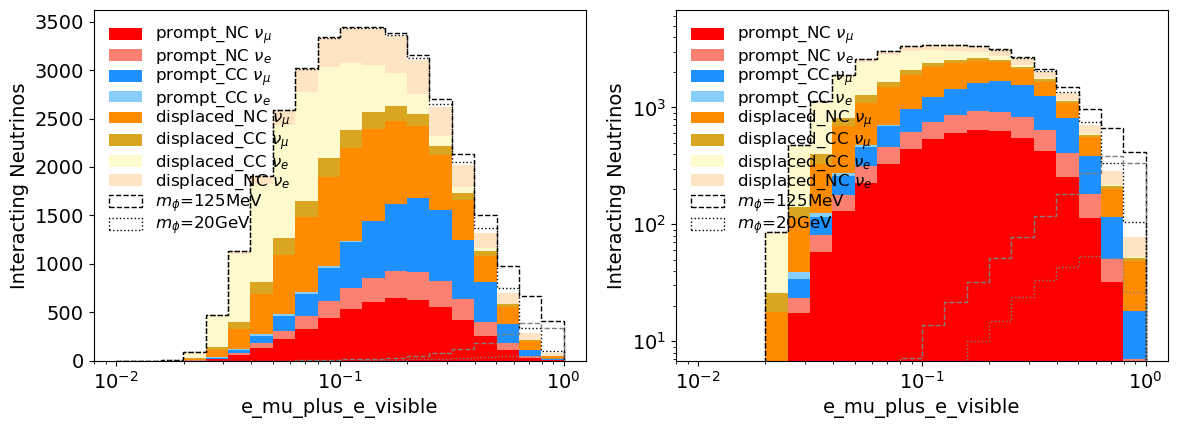

In [24]:
get_stacked_histogram(
    data=data, 
    observable="e_mu_plus_e_visible", 
    bins=np.logspace(-2,0,20+1), 
    xlabel="e_mu_plus_e_visible", 
    xlog=True,
    signals = {'0.125GeV':[0.1,"$m_{\phi}$=125MeV","dashed"], '19.95GeV':[1,"$m_{\phi}$=20GeV","dotted"]},
)

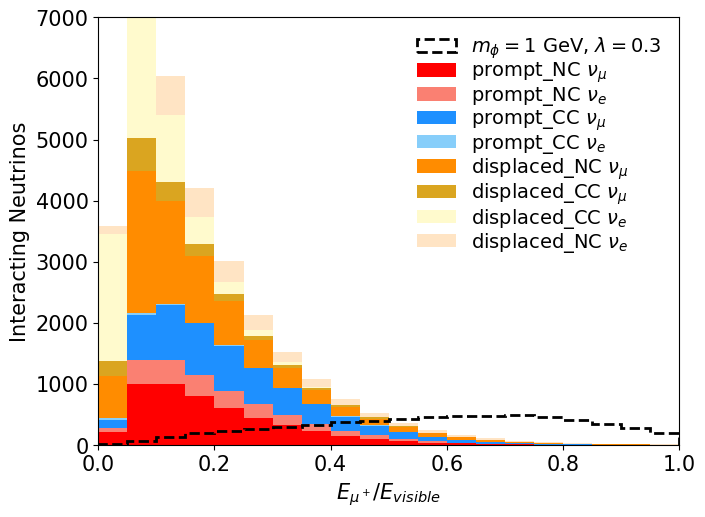

In [25]:
get_stacked_histogram_paper(
    data=data, 
    observable="e_mu_plus_e_visible", 
    bins=np.linspace(0,1,20+1), 
    xlabel=r"$E_{\mu^+} / E_{visible}$", 
    xlog=False,
    signals = {'1GeV':[0.3,"$m_{\phi}=1~$GeV, $\lambda=0.3$","dashed"]},
    ylim=[0,7000],
)

We cut on $E_\mu^+$/$E_{visible} > 0.6$. **Changed the cut from 0.5-0.6 to reduce more number of events** 

In [26]:
data = data[data['e_mu_plus_e_visible']>0.6].copy()
rates = get_rates(data)
results['e_mu_evis'] = {'color':'crimson', 'label':r'$E_{\mu^+} / E_{vis}$', 'numbers':rates, 'ls':'dashed'}

   CC_numu: 105.4 (N_MC = 5601)
   CC_nuebar: 0.104 (N_MC = 5)
   NC_numu: 53.705 (N_MC = 4447)
   NC_nuebar: 30.222 (N_MC = 4816)
   CC_numu_displaced: 20.171 (N_MC = 983)
   CC_nuebar_displaced: 2.895 (N_MC = 182)
   NC_numu_displaced: 151.889 (N_MC = 4954)
   NC_nuebar_displaced: 117.65 (N_MC = 6061)
   Total Background: 482.035 (N_MC = 27049)
   0.001GeV: 209584.215 (N_MC = 71266): g>0.014475
   0.01GeV: 153369.458 (N_MC = 70678): g>0.016921
   0.125GeV: 88555.492 (N_MC = 67369): g>0.022268
   1GeV: 38596.584 (N_MC = 58899): g>0.03373
   7.94GeV: 3305.397 (N_MC = 34093): g>0.115258
   19.95GeV: 94.348 (N_MC = 32926): g>0.68221
   30GeV: 2.298 (N_MC = 8188): g>4.371447


### 4. Charm Veto

One of the main sources of $\mu^+$ are charm hadron decays $X_c \to X_s \mu^+ \nu $. We assume an 80% charm tagging efficiency. 

In [27]:
veto_prob = 0.8
data = data.copy()
data['ctag_prob'] = 1 - data['has_charm'] * veto_prob
data['weight'] = data['weight'] * data['ctag_prob']

In [28]:
rates = get_rates(data)
results['charm_veto'] = {'color':'r', 'label':r'charm veto', 'numbers':rates, 'ls':'dashdot'}

   CC_numu: 21.273 (N_MC = 5601)
   CC_nuebar: 0.061 (N_MC = 5)
   NC_numu: 12.2 (N_MC = 4447)
   NC_nuebar: 6.977 (N_MC = 4816)
   CC_numu_displaced: 20.136 (N_MC = 983)
   CC_nuebar_displaced: 1.77 (N_MC = 182)
   NC_numu_displaced: 151.479 (N_MC = 4954)
   NC_nuebar_displaced: 117.401 (N_MC = 6061)
   Total Background: 331.296 (N_MC = 27049)
   0.001GeV: 200302.79 (N_MC = 71266): g>0.013481
   0.01GeV: 146649.715 (N_MC = 70678): g>0.015755
   0.125GeV: 84861.901 (N_MC = 67369): g>0.020712
   1GeV: 37428.387 (N_MC = 58899): g>0.031187
   7.94GeV: 3271.758 (N_MC = 34093): g>0.105482
   19.95GeV: 94.159 (N_MC = 32926): g>0.621783
   30GeV: 2.296 (N_MC = 8188): g>3.981773


### 5. Phi Angle

At this stage, NC events are the main bakground. In this case, we expect the $\mu^+$ (from D decay) and missing momentum to be back to back. So the phi angle between them should be large. For the signal, this angle should have a more flat distribution. Let's check that.

In [29]:
data['dphi'] = abs ( (data['phi_mu_plus']-data['phi_mis'] + np.pi) % (2 * np.pi) - np.pi ) 

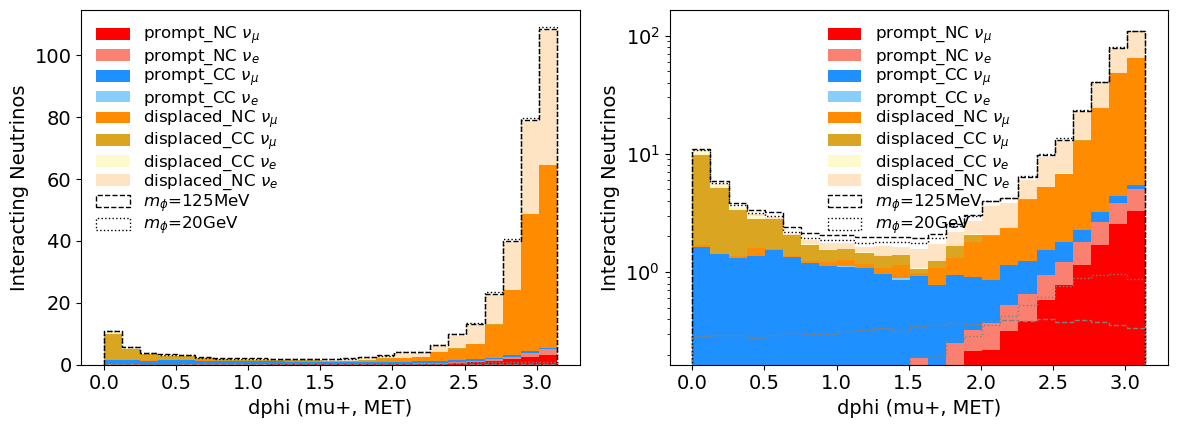

In [30]:
get_stacked_histogram(
    data=data, 
    observable="dphi", 
    bins=np.linspace(0,np.pi,25+1), 
    xlabel="dphi (mu+, MET)", 
    xlog=False,
    signals = {'0.125GeV':[0.01,"$m_{\phi}$=125MeV","dashed"], '19.95GeV':[.3,"$m_{\phi}$=20GeV","dotted"]},
)

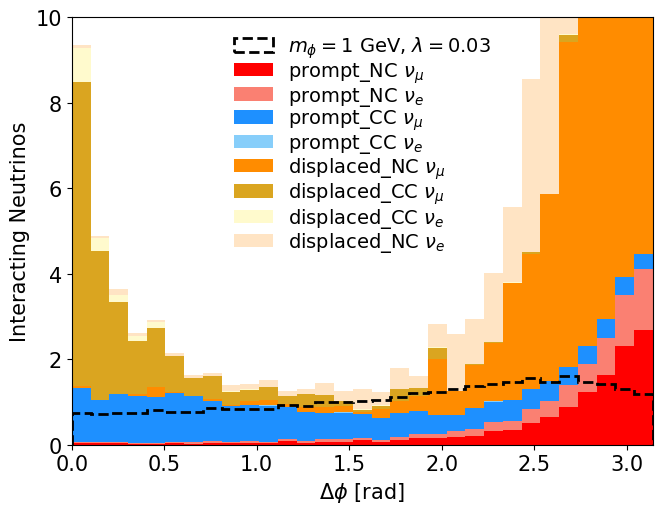

In [31]:
get_stacked_histogram_paper(
    data=data, 
    observable="dphi", 
    bins=np.linspace(0,np.pi,31+1), 
    xlabel=r"$\Delta \phi$ [rad]", 
    xlog=False,
    signals = {'1GeV':[0.03,"$m_{\phi}=1~$GeV, $\lambda=0.03$","dashed"]},
    ylim=[0,10],
)

Let's also look at the pT of the $\mu^+$ and MET. The former seems to be more powerful to suppress CC backgrounds and less sensitive to the scalar mass. 

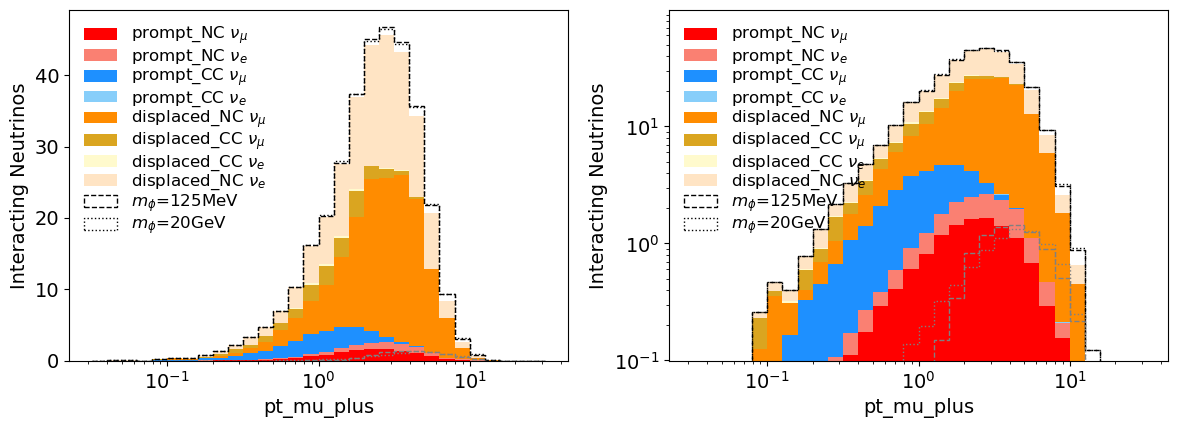

In [32]:
get_stacked_histogram(
    data=data, 
    observable="pt_mu_plus", 
    bins=np.logspace(-1.5,1.5,30+1), 
    xlabel="pt_mu_plus", 
    xlog=True,
    signals = {'0.125GeV':[0.01,"$m_{\phi}$=125MeV","dashed"], '19.95GeV':[.3,"$m_{\phi}$=20GeV","dotted"]},
)

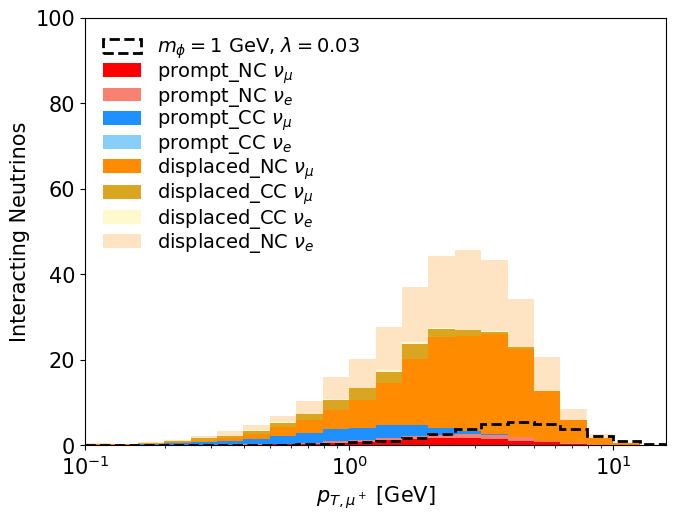

In [33]:
get_stacked_histogram_paper(
    data=data, 
    observable="pt_mu_plus", 
    bins=np.logspace(-1,1.2,22+1), 
    xlabel=r"$p_{T,\mu^+}$ [GeV]", 
    xlog=True,
    signals = {'1GeV':[0.03,"$m_{\phi}=1~$GeV, $\lambda=0.03$","dashed"]},
    ylim=[0,100],
    loc='upper left',
)

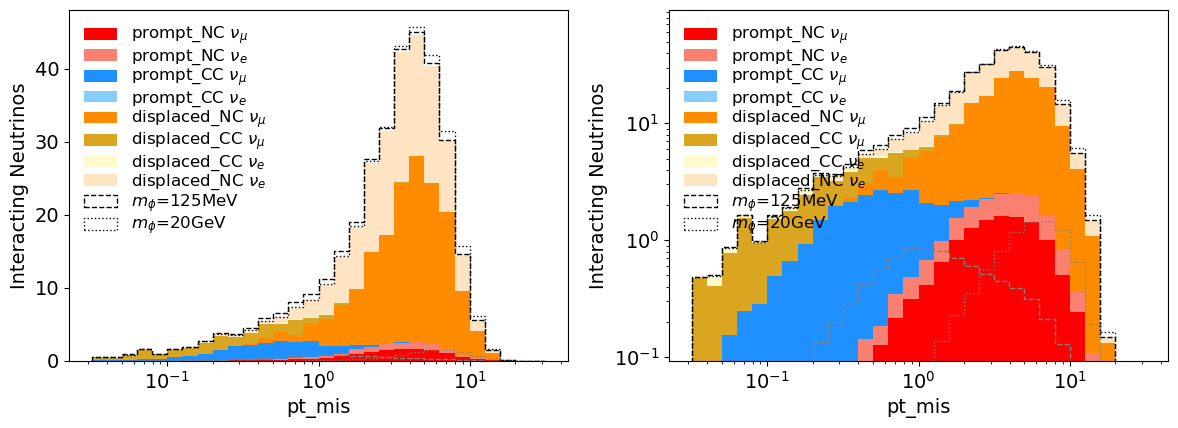

In [34]:
get_stacked_histogram(
    data=data, 
    observable="pt_mis", 
    bins=np.logspace(-1.5,1.5,30+1), 
    xlabel="pt_mis", 
    xlog=True,
    signals = {'0.125GeV':[0.01,"$m_{\phi}$=125MeV","dashed"], '19.95GeV':[.3,"$m_{\phi}$=20GeV","dotted"]},
)

We can be slightly smarter and impose a 2D cut. This way, a bit more of the signal survives. 

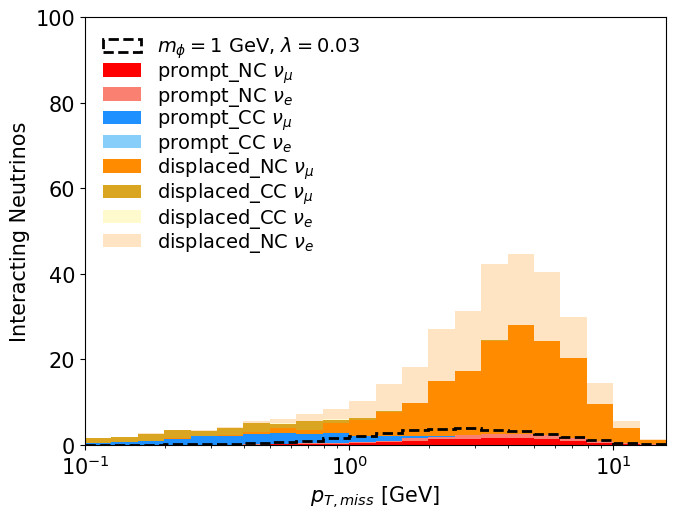

In [35]:
get_stacked_histogram_paper(
    data=data, 
    observable="pt_mis", 
    bins=np.logspace(-1,1.2,22+1), 
    xlabel=r"$p_{T,miss}$ [GeV]", 
    xlog=True,
    signals = {'1GeV':[0.03,"$m_{\phi}=1~$GeV, $\lambda=0.03$","dashed"]},
    ylim=[0,100],
    loc='upper left',
)

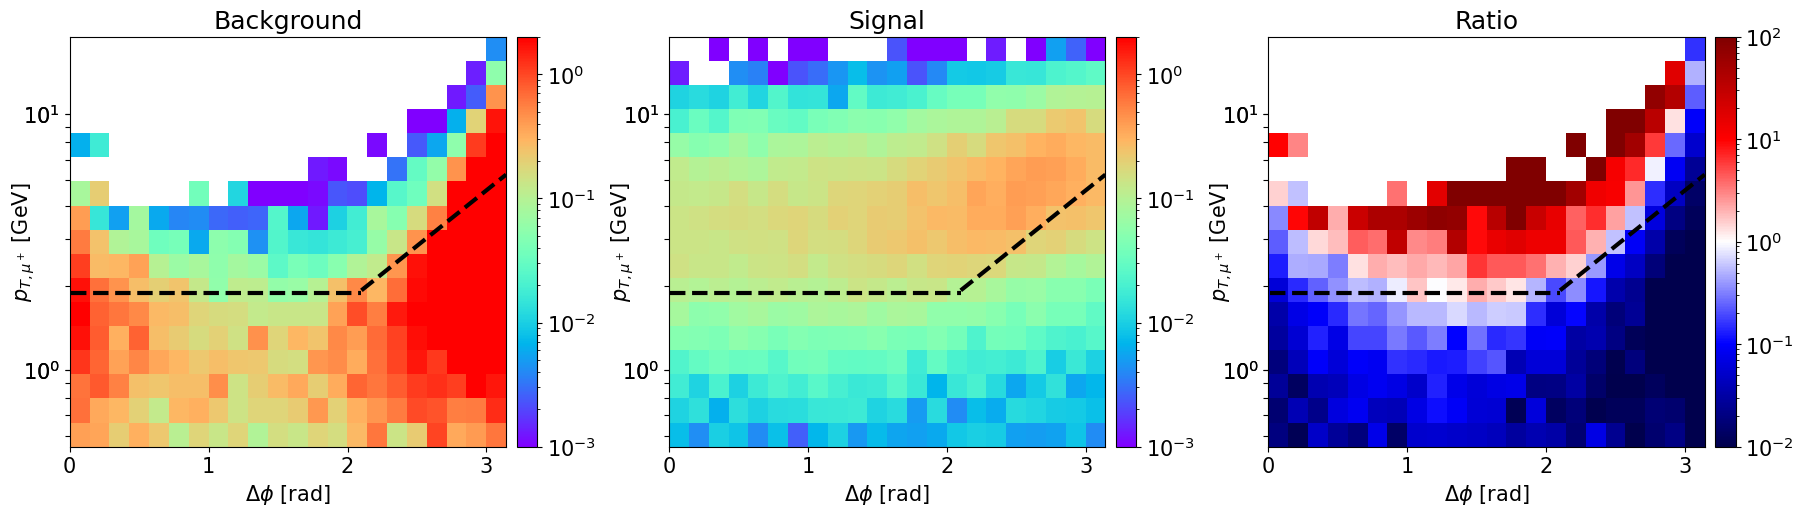

In [36]:
varx = 'dphi'
vary = 'pt_mu_plus'


data['pt_mis'] = pd.to_numeric(data['pt_mis'], errors='coerce').abs()
data['weight'] = pd.to_numeric(data['weight'], errors='coerce')
plot_2d(
    data0 = data[data['set'].isin(['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar',"CC_numu_displaced","CC_nuebar_displaced","NC_numu_displaced","NC_nuebar_displaced"])],
    data1 = data[data['set'].isin(['1GeV'])],
    varx = varx,
    vary = vary,
    logx=False,
    binsx = [0, np.pi, 21],
    binsy = [np.log10(0.5), np.log10(20), 16],
    lines = [ [[1e-2,2.1],[2,2]], [np.linspace(2.1,np.pi,20), [ 0.25*np.exp(x) for x in np.linspace(2.1,np.pi,20)]]],
    coupling1=0.03,
    labelx = r'$\Delta \phi$ [rad]',
    labely = r'$p_{T,\mu^+}$ [GeV]',
    zlims = [1e-3, 2e0],
    ylabelpad=-10,
)

## Let's plot the same as contour plot

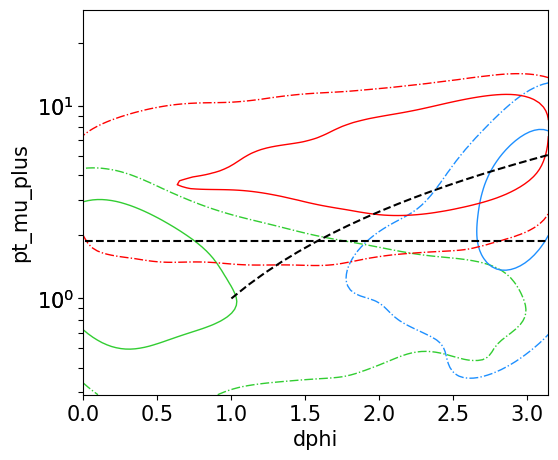

In [37]:
sets = {
    'CC':  [['CC_numu', 'CC_nuebar',"CC_numu_displaced","CC_nuebar_displaced"], 'limegreen', 'CC Bkg'], 
    'NC':  [['NC_numu', 'NC_nuebar',"NC_numu_displaced","NC_nuebar_displaced"], 'dodgerblue', 'NC Bkg'], 
    'Sig': [['1GeV'], 'red', r'$m_\phi=1$GeV'], 
}
        
        
plot_contour(
    data, 
    sets,
    varx = varx,
    vary = vary,
    logx = False,
    logy = True,
    binsx = [0, np.pi, 32],
    binsy = [-0.5, 1.5, 21],
    lines = [ [[1e-2,1e2],[2,2]], [np.linspace(1,np.pi,20), [ x**1.5 for x in np.linspace(1,np.pi,20)]]]  ,
    nmax=10000,
)


**Changed data['pt_mu_plus']>2 to data['pt_mu_plus']>2.5**

In [38]:
data = data[data['pt_mu_plus']>2.5]
#data = data[data['pt_mu_plus']>data['dphi']**1.5].copy()
data = data[data['pt_mu_plus']>0.25*np.exp(data['dphi'])].copy()

rates = get_rates(data)
results['dphi'] = {'color':'orangered', 'label':r'$p_{T,\mu^+} vs. \Delta\phi$', 'numbers':rates, 'ls':(5, (10, 3))}

rates = get_rates(data, big_det=True, do_print=False)
results_big['dphi'] = {'color':'orangered', 'label':r'$p_{T,\mu^+} vs. \Delta\phi$', 'numbers':rates, 'ls':(5, (10, 3))}

   CC_numu: 0.977 (N_MC = 206)
   CC_nuebar: 0.058 (N_MC = 4)
   NC_numu: 1.564 (N_MC = 573)
   NC_nuebar: 1.168 (N_MC = 1019)
   CC_numu_displaced: 2.266 (N_MC = 94)
   CC_nuebar_displaced: 0.27 (N_MC = 25)
   NC_numu_displaced: 19.765 (N_MC = 577)
   NC_nuebar_displaced: 10.57 (N_MC = 615)
   Total Background: 36.639 (N_MC = 3113)
   0.001GeV: 153231.475 (N_MC = 44335): g>0.008888
   0.01GeV: 111349.217 (N_MC = 43540): g>0.010427
   0.125GeV: 63758.167 (N_MC = 40771): g>0.013779
   1GeV: 27238.346 (N_MC = 33558): g>0.021082
   7.94GeV: 2269.082 (N_MC = 18580): g>0.073043
   19.95GeV: 60.67 (N_MC = 16627): g>0.446697
   30GeV: 1.252 (N_MC = 3474): g>3.110004


Let's check the histogram wrt muon+ energy after the cuts

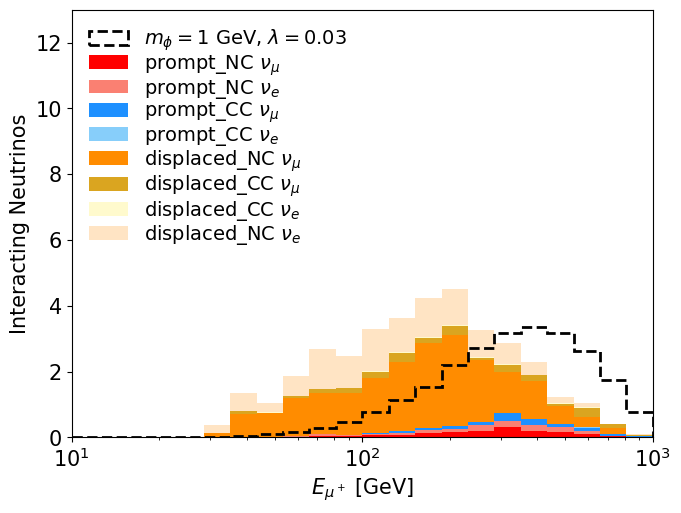

In [39]:
get_stacked_histogram_paper(
    data=data, 
    observable="e_mu_plus", 
    bins=np.logspace(1,3,22+1), 
    xlabel=r"$E_{\mu^+}$ [GeV]", 
    xlog=True,
    signals = {'1GeV':[0.03,"$m_{\phi}=1~$GeV, $\lambda=0.03$","dashed"]},
    ylim=[0,13],
    loc='upper left',
)

At this stage, we essentially have no BG. So let's stop and look a the reach. 

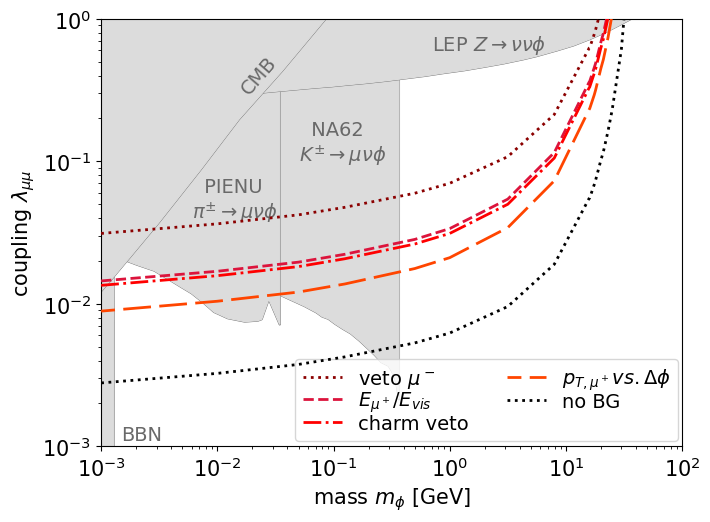

In [40]:
plot_reach(
    results, 
    order = ['baseline', 'e_mu_evis', 'charm_veto', 'dphi', 'noBG'],
)

## ML-based analysis

Let us now consider to throw a bunch of variables into a BDT. We start with the baseline data (for which we required a $\mu^+$ with $E>30$ GeV and veto events with a $\mu^-$ of energy $E>10$ GeV. 

### 1. Preparation

Let us first add a variable that decides whether an event was charged tagged. Let's also add back `dphi`.

In [41]:
data = data_baseline.copy()
data['random'] = np.random.random(len(data))
data['charm_tag'] = ((data['has_charm'] * data['random']) > veto_prob).astype(int)
data['dphi'] = abs ( (data['phi_mu_plus']-data['phi_mis'] + np.pi) % (2 * np.pi) - np.pi ) 

Let us look again at the rates

In [42]:
_=get_rates(data, header = r"Before BDT")

Before BDT:
   CC_numu: 5388.495 (N_MC = 219864)
   CC_nuebar: 110.656 (N_MC = 6616)
   NC_numu: 5004.596 (N_MC = 421414)
   NC_nuebar: 2224.785 (N_MC = 376474)
   CC_numu_displaced: 1675.462 (N_MC = 14333)
   CC_nuebar_displaced: 7256.312 (N_MC = 63153)
   NC_numu_displaced: 8047.34 (N_MC = 104303)
   NC_nuebar_displaced: 3185.126 (N_MC = 87243)
   Total Background: 32892.773 (N_MC = 1293400)
   0.001GeV: 372999.667 (N_MC = 120247): g>0.031184
   0.01GeV: 273573.301 (N_MC = 119172): g>0.036413
   0.125GeV: 160346.449 (N_MC = 116618): g>0.047562
   1GeV: 73765.976 (N_MC = 110660): g>0.070123
   7.94GeV: 7974.186 (N_MC = 83606): g>0.213278
   19.95GeV: 272.07 (N_MC = 100841): g>1.154648
   30GeV: 7.197 (N_MC = 29326): g>7.099487


Let's choose all the input features 
- `e_mu_plus` energy of mu+
- `e_em`: energy of EM shower
- `charm_tag`: whether a charm was tagged in the event
- `e_visible`: visible energy
- `pt_mis`: missing pT
- `ht`: HT as scalar sum of all visible particles
- `pt_mu_plus`: pT of mu+
- `dphi`: absolute phi difference between mu+ and MET

We store them in an array `X`. `y` corresponds to the datasets. 

In [43]:
features = ['e_mu_plus', 'e_em', 'has_charm', 'e_visible', 'pt_mis', 'ht', 'pt_mu_plus',  'dphi', 'truth_energy']
X, yset, weights = data[features], data['set'], data['weight']

### 2. ML Training

Let's now run the usual ML training routine

In [44]:
#Define preprocessing: log-transform and scaling
test_size=0.75
X_train, X_test, yset_train, yset_test, weights_train, weights_test = train_test_split(
    X, yset, weights, test_size=test_size, random_state=42
)

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
yset_train.reset_index(drop=True, inplace=True)
yset_test.reset_index(drop=True, inplace=True)
weights_train.reset_index(drop=True, inplace=True)
weights_test.reset_index(drop=True, inplace=True)

y_train = pd.Series([0 if y in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar',"NC_numu_displaced","NC_nuebar_displaced","CC_numu_displaced","CC_nuebar_displaced"] else 1 for y in yset_train])
y_test  = pd.Series([0 if y in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar',"NC_numu_displaced","NC_nuebar_displaced","CC_numu_displaced","CC_nuebar_displaced"] else 1 for y in yset_test])

X_train = X_train[features[:-1]]
T_test = X_test[['truth_energy']]
X_test = X_test[features[:-1]]

In [45]:
# use only some signals 
select = ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar',"NC_numu_displaced","NC_nuebar_displaced","CC_numu_displaced","CC_nuebar_displaced", "0.125GeV", "1GeV", "7.94GeV", "19.95GeV"]
selected = pd.Series([1 if y in select else 0 for y in yset_train]).astype(bool)

yset_train_sel = yset_train[selected].reset_index(drop=True)
y_train_sel = y_train[selected].reset_index(drop=True)
X_train_sel = X_train[selected].reset_index(drop=True)
weights_train_sel = weights_train[selected].reset_index(drop=True)

In [46]:
# normalize background weights to 1
y_selected = pd.Series([1 if y in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar',"NC_numu_displaced","NC_nuebar_displaced","CC_numu_displaced","CC_nuebar_displaced"] else 0 for y in yset_train_sel])
weights_train_sel_reduced = weights_train_sel * y_selected / sum(weights_train_sel*y_selected)
                       
#normalize 4 of the signals to 0.01, remove the rest 
signal_norm = 0.0025
for dataset in ["0.125GeV", "1GeV", "7.94GeV", "19.95GeV"]:
    y_selected = pd.Series([1 if y in [dataset] else 0 for y in yset_train_sel])
    weights_train_sel_reduced += weights_train_sel * y_selected / sum(weights_train_sel*y_selected) * signal_norm

In [47]:
#Create a pipeline with preprocessing and the classifier
pipeline = Pipeline([
    ('scale', QuantileTransformer()) ,   
    ('bdt', GradientBoostingClassifier(
        n_estimators=200, 
        learning_rate=0.03, 
        max_depth=3, 
        #random_state=42,
        min_samples_split=5,
        min_samples_leaf=5,
        max_features='sqrt',
        subsample=0.8,
    ))
])

In [48]:
# train BDT
_=pipeline.fit(X_train_sel, y_train_sel, bdt__sample_weight=weights_train_sel_reduced)

In [49]:
# Make predictions
y_pred = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred_prob_train_sel = pipeline.predict_proba(X_train_sel)[:, 1]
y_pred_prob_train = pipeline.predict_proba(X_train)[:, 1]

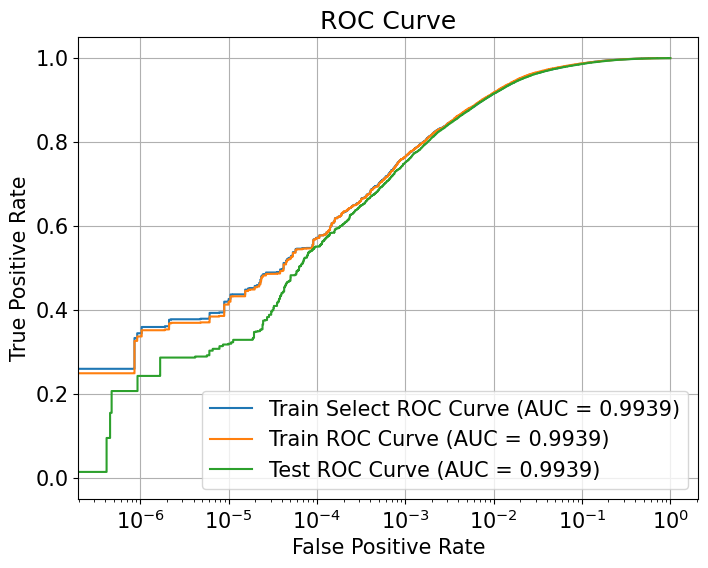

In [50]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred, sample_weight=weights_test)
roc_auc = roc_auc_score(y_test, y_pred_prob, sample_weight=weights_test)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_train_sel, y_pred_prob_train_sel, sample_weight=weights_train_sel)
plt.plot(fpr, tpr, label=f'Train Select ROC Curve (AUC = {roc_auc:.4f})')
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob_train, sample_weight=weights_train)
plt.plot(fpr, tpr, label=f'Train ROC Curve (AUC = {roc_auc:.4f})')
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, sample_weight=weights_test)
plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {roc_auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Let us now store the results. `yprob` is the BDT output variable. 

In [51]:
processed = X_test.copy()
processed['truth_energy'] = T_test['truth_energy']
processed['set'] = yset_test
processed['y'] = np.array(y_test)
processed['ypred'] = y_pred
processed['yprob'] = y_pred_prob
processed['weight'] = weights_test / test_size

### 3. ML Results analysis

Let's plot it

Let us quickly check that the `processed` sample prediction (before cuts) agree with the oes of the full sample. They do. 

In [52]:
_=get_rates(processed, header = r"After BDT")

After BDT:
   CC_numu: 5393.877 (N_MC = 164775)
   CC_nuebar: 110.394 (N_MC = 4911)
   NC_numu: 5007.131 (N_MC = 316385)
   NC_nuebar: 2229.51 (N_MC = 282586)
   CC_numu_displaced: 1676.704 (N_MC = 10762)
   CC_nuebar_displaced: 7233.06 (N_MC = 47183)
   NC_numu_displaced: 8081.063 (N_MC = 78322)
   NC_nuebar_displaced: 3170.442 (N_MC = 65336)
   Total Background: 32902.182 (N_MC = 970260)
   0.001GeV: 373537.113 (N_MC = 90186): g>0.031164
   0.01GeV: 273508.485 (N_MC = 89613): g>0.03642
   0.125GeV: 159914.542 (N_MC = 87464): g>0.04763
   1GeV: 73676.417 (N_MC = 82738): g>0.070171
   7.94GeV: 7971.535 (N_MC = 62746): g>0.213329
   19.95GeV: 272.199 (N_MC = 75623): g>1.154458
   30GeV: 7.143 (N_MC = 21868): g>7.126495


Let's look at the `yprob` distribution. 

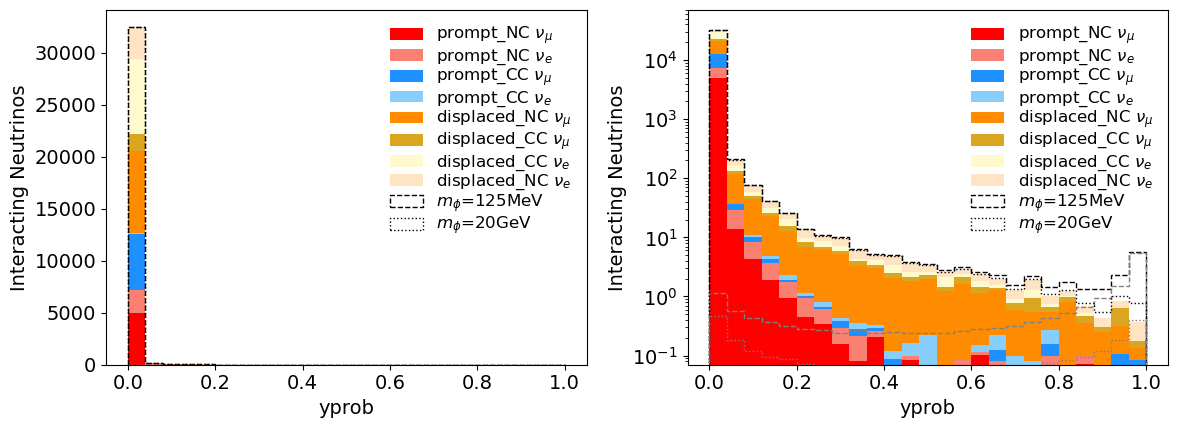

In [53]:
get_stacked_histogram(
    data=processed, 
    observable="yprob", 
    bins=np.linspace(0,1,25+1), 
    xlabel="yprob", 
    xlog=False,
    yspread=1e6,
    signals = {'0.125GeV':[0.01,"$m_{\phi}$=125MeV","dashed"], '19.95GeV':[0.1,"$m_{\phi}$=20GeV","dotted"]},
)

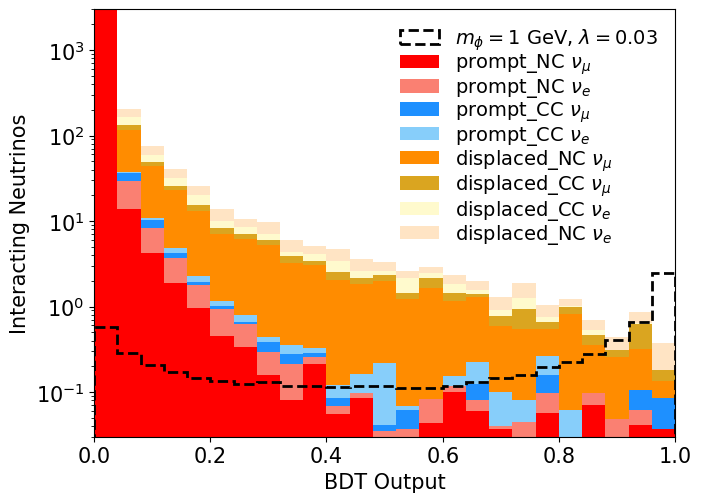

In [54]:
get_stacked_histogram_paper(
    data=processed, 
    observable="yprob", 
    bins=np.linspace(0,1,25+1), 
    xlabel=r"BDT Output", 
    xlog=False,
    signals = {'1GeV':[0.01,"$m_{\phi}=1~$GeV, $\lambda=0.03$","dashed"]},
    ylim=[3e-2,3e3],
    loc='upper right',
    ylog=True,
)

Let's choose a cutoff of 0.9 and see what happens

In [55]:
for val in [0.65, 0.66, 0.67,0.68,  0.7, 0.72, 0.75, 0.8, 0.85, 0.9]:
    passed = processed[processed['yprob']>val]
    rates = get_rates(passed, header = r"After BDT > " + str(val), do_print = False)
    for dataset in ['1GeV']:
        print ("   "+dataset + ": " + str(round(rates['1GeV'][0],3)) + ", "+  str(round(rates['1GeV'][2],5)))

After BDT > 0.65:
   1GeV: 46216.181, 0.01149
After BDT > 0.66:
   1GeV: 45917.877, 0.01134
After BDT > 0.67:
   1GeV: 45591.894, 0.01125
After BDT > 0.68:
   1GeV: 45243.125, 0.0111
After BDT > 0.7:
   1GeV: 44524.201, 0.01107
After BDT > 0.72:
   1GeV: 43772.116, 0.01079
After BDT > 0.75:
   1GeV: 42634.471, 0.01034
After BDT > 0.8:
   1GeV: 40242.75, 0.00969
After BDT > 0.85:
   1GeV: 37388.296, 0.00898
After BDT > 0.9:
   1GeV: 33343.741, 0.00949


In [56]:
passed = processed[processed['yprob']>0.7]
rates = get_rates(passed, header = r"After BDT > " + str(val))
results['BDT'] = {'color':'darkorange', 'label':r'BDT', 'numbers':rates, 'ls':'solid'}

After BDT > 0.9:
   CC_numu: 0.154 (N_MC = 3)
   CC_nuebar: 0.195 (N_MC = 7)
   NC_numu: 0.281 (N_MC = 18)
   NC_nuebar: 0.138 (N_MC = 16)
   CC_numu_displaced: 1.361 (N_MC = 23)
   CC_nuebar_displaced: 0.66 (N_MC = 22)
   NC_numu_displaced: 2.574 (N_MC = 98)
   NC_nuebar_displaced: 2.076 (N_MC = 143)
   Total Background: 7.439 (N_MC = 330)
   0.001GeV: 231018.344 (N_MC = 37764): g>0.004859
   0.01GeV: 169546.95 (N_MC = 37800): g>0.005672
   0.125GeV: 99166.122 (N_MC = 37461): g>0.007417
   1GeV: 44524.201 (N_MC = 35345): g>0.011069
   7.94GeV: 4020.919 (N_MC = 22663): g>0.036833
   19.95GeV: 105.156 (N_MC = 20187): g>0.22776
   30GeV: 1.922 (N_MC = 3838): g>1.684462


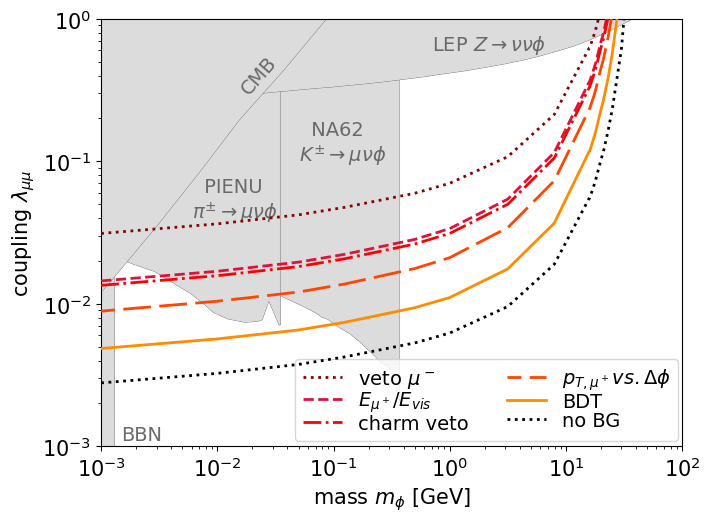

In [57]:
plot_reach(
    results, 
    order = ['baseline', 'e_mu_evis', 'charm_veto', 'dphi', 'BDT', 'noBG',],
)

### 4. Big Detector

In [58]:
for val in [0.65, 0.7, 0.8, 0.9, 0.95]:
    passed = processed[processed['yprob']>val]
    rates = get_rates(passed, header = r"After BDT > " + str(val), do_print = False, big_det = True)
    for dataset in ['1GeV']:
        print ("   "+dataset + ": " + str(round(rates['1GeV'][0],3)) + ", "+  str(round(rates['1GeV'][2],5)))

After BDT > 0.65:
   1GeV: 46216181.242, 0.00204
After BDT > 0.7:
   1GeV: 44524200.753, 0.00197
After BDT > 0.8:
   1GeV: 40242749.959, 0.00172
After BDT > 0.9:
   1GeV: 33343741.337, 0.0015
After BDT > 0.95:
   1GeV: 26692010.796, 0.00145


In [59]:
passed = processed[processed['yprob']>0.9]
rates = get_rates(passed, header = r"After BDT > " + str(val), big_det = True)
results_big['BDT_big'] = {'color':'red', 'label':r'MuCol$\nu$ 10 ton$\times$year', 'numbers':rates, 'ls':'dashed'}

After BDT > 0.95:
   CC_numu: 93.467 (N_MC = 2)
   CC_nuebar: 0 (N_MC = 0)
   NC_numu: 102.803 (N_MC = 6)
   NC_nuebar: 40.584 (N_MC = 4)
   CC_numu_displaced: 352.992 (N_MC = 4)
   CC_nuebar_displaced: 19.654 (N_MC = 1)
   NC_numu_displaced: 310.309 (N_MC = 17)
   NC_nuebar_displaced: 485.562 (N_MC = 31)
   Total Background: 1405.37 (N_MC = 65)
   0.001GeV: 169255155.479 (N_MC = 25021): g>0.000666
   0.01GeV: 125039974.236 (N_MC = 25200): g>0.000774
   0.125GeV: 73393929.882 (N_MC = 25208): g>0.001011
   1GeV: 33343741.337 (N_MC = 24149): g>0.0015
   7.94GeV: 2807106.326 (N_MC = 14631): g>0.005168
   19.95GeV: 64640.62 (N_MC = 11744): g>0.034057
   30GeV: 1056.908 (N_MC = 1978): g>0.266345


In [60]:
def baseline_plot():
    
    # setup figure
    matplotlib.rcParams.update({'font.size': 15})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(7,5))
        
    # datasets
    constraints = {
        'BBN': ['BBN', 1.5e-3, 1.1e-3, 0],
        #'0v2b': [r'0$\nu$2$\beta$', 2.3e-3, 1.1e-3, 0],
        'NA62': ['  NA62\n'+r'$K^{\pm}\rightarrow l\nu\phi$', 5e-2, 1e-1, 0],
        'PIENU': ['  PIENU\n'+r'$\pi^{\pm}\rightarrow l\nu\phi$', 0.6e-2, 4e-2, 0],
        'Zdecay': [r"LEP $Z\rightarrow inv.$ ", 0.7, 6e-1, 0],
        'CMB': ['CMB', 15e-3, 3e-1, 49],
    }
    zorder=-100
    for bound in constraints.keys():
        label, x, y, rot = constraints[bound]
        data = np.loadtxt('lines/Bound_'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color="dimgray", ls='solid', zorder=zorder)
        plt.fill(data.T[0], data.T[1], color="gainsboro", zorder=zorder)
        plt.text(x, y, label, fontsize=14, color='dimgray', rotation=rot)
        zorder+=1
        
    # finalize
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1e-3, 1e2)
    plt.ylim(1e-3, 1e0)
    plt.xlabel(r'mass $m_\phi$ [GeV]')
    plt.ylabel(r'coupling $\lambda$')
    return plt, fig

In [61]:
def baseline_plot_big(plot_y1=False):
    
    # setup figure
    matplotlib.rcParams.update({'font.size': 15})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(7,5))
    
    # future
    future = {
        'DUNE': ['DUNE', 4e-1, 2.5e-2, 0, 'dodgerblue', 'dashed'], 
        'HLLHC_Hinv': [r"HL-LHC", 4e-1, 2.5e-1, 0, 'royalblue', 'dashed'],   
        '10tonne_FLARE': ['FLARE', 4e-1, 1.8e-1, 0, 'blue', 'dashed'],   
        'IceCube_Gen-2': ["IC Gen-2", 7e-3, 3e-4, 0, 'deepskyblue', 'dashed'],   
        #'Sebastian_talk_3': ["", 7e-2, 1.6e-4, 0, 'midnightblue', 'dashed'],           
    }
    zorder=-100
    for bound in future.keys():
        label, x, y, rot, col, ls = future[bound]
        data = np.loadtxt('lines/Project_'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color=col, ls=ls, zorder=zorder, lw=0.8)
        plt.text(x, y, label, fontsize=13, color=col, rotation=rot)
        zorder+=1
        
    # datasets
    constraints = {
        'BBN': ['BBN', 1.5e-3, 1.1e-4, 0],
        #'0v2b': [r'0$\nu$2$\beta$', 2.3e-3, 1.1e-3, 0],
        'NA62': ['  NA62\n'+r'$K^{\pm}\rightarrow \mu\nu\phi$', 5e-2, 3e-2, 0],
        'PIENU': ['  PIENU\n'+r'$\pi^{\pm}\rightarrow \mu\nu\phi$', 0.6e-2, 3e-2, 0],
        'Zdecay': [r"LEP $Z\rightarrow \nu \nu \phi$ ", 0.5, 6e-1, 0],
        'CMB': ['CMB', 15e-3, 3e-1, 49],
    }
    for bound in constraints.keys():
        label, x, y, rot = constraints[bound]
        data = np.loadtxt('lines/Bound_'+bound+'.txt')
        plt.plot(data.T[0], data.T[1], color="dimgray", ls='solid', zorder=zorder)
        plt.fill(data.T[0], data.T[1], color="gainsboro", zorder=zorder)
        plt.text(x, y, label, fontsize=14, color='dimgray', rotation=rot)
        zorder+=1
        
    # plot H>inv
    data = np.loadtxt('lines/Project_MC3_Hinv.txt')
    plt.plot(data.T[0], data.T[1], color="darkorange", ls='dashdot', zorder=10,lw=2, label=r'MuCol   $h \to inv$')
         
    # datasets
    targets = {
        'Target_ComplexScalar': ['Complex Scalar', 0.7e-2, 0.66e-3, 40,'dotted'],
        'Target_DiracFermion': ['Dirac Fermion', 2.5e-2, 1e-4, 40,'dashdot'],
        'Target_SterileNeutrino': [r"Sterile $\nu$", 1.6, 9e-4, 0,'dashed'],
    }
    for bound in targets.keys():
        label, x, y, rot, ls = targets[bound]
        data = np.loadtxt('lines/'+bound+'.txt')
        if bound in ['Target_ComplexScalar','Target_DiracFermion'] and plot_y1: 
            plt.plot(data.T[0], data.T[1]**2, color='k', ls=ls,lw=2)
        else: 
            plt.plot(data.T[0], data.T[1], color='k', ls=ls,lw=2)
        plt.text(x, y, label, fontsize=13, color='k', rotation=rot)

        
    # finalize
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1e-3, 1e2)
    plt.ylim(1e-4, 1e0)
    plt.xlabel(r'mass $m_\phi$ [GeV]')
    plt.ylabel(r'coupling $\lambda_{\mu\mu}$')
    return plt, fig

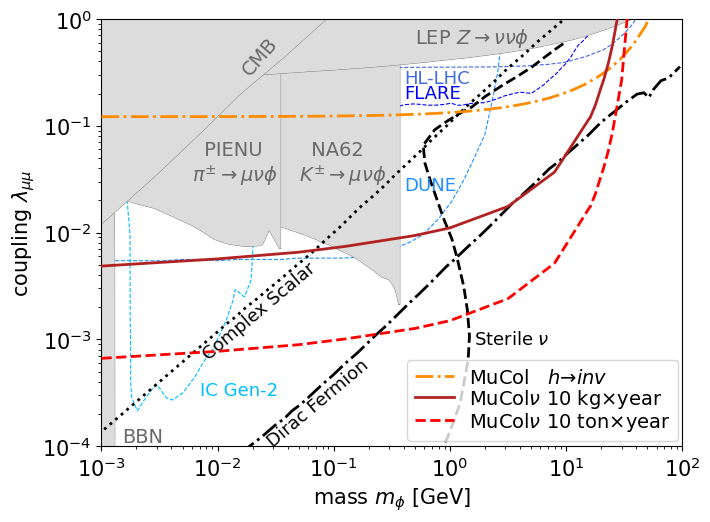

In [62]:
results_big['BDT_small'] = {'color':'firebrick', 'label':r'MuCol$\nu$ 10 kg$\times$year', 'numbers':results['BDT']['numbers'], 'ls':'solid'}

plot_reach(
    results_big, 
    big_det=True,
    order = ['BDT_small','BDT_big'],#,'noBG'],
    ncol=1,
    plot_y1=True,
)

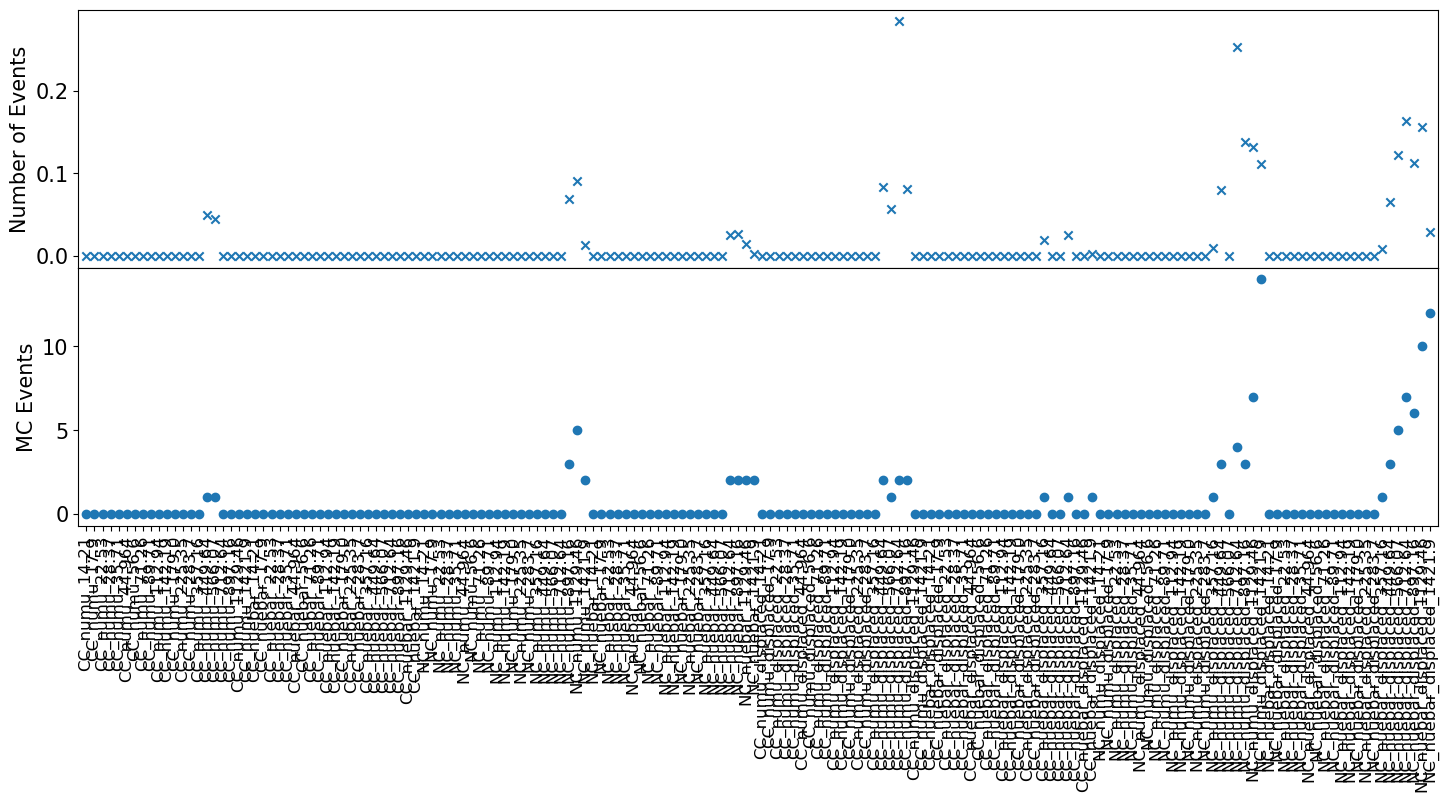

In [63]:
plot_highend(processed, 0.85)

### 5. Feature Importance

In [64]:
# Access the trained classifier (bdt)
gbc = pipeline.named_steps['bdt']

# Extract feature importances
importances = gbc.feature_importances_

# If you have feature names, create a DataFrame for better visualization
import pandas as pd
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming you have feature names in X_train
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the feature importance
print(feature_importance_df)

      Feature  Importance
6  pt_mu_plus    0.437062
7        dphi    0.165332
0   e_mu_plus    0.163059
2   has_charm    0.059277
4      pt_mis    0.055768
1        e_em    0.048965
3   e_visible    0.042336
5          ht    0.028201


In [65]:
def latex(x):
    
    if x >1 and x < 100: return str(round(x,2)) 
    if x >0.01 and x < 1: return str(round(x,3)) 
    latex_format = r"{:.2e}".format(x)
    latex_format = latex_format.replace('e', r' \cdot 10^{')
    latex_format = latex_format.replace('+0', '+') 
    latex_format = latex_format.replace('-0', '-') 
    latex_format = latex_format.replace('+', '') + '}'
    latex_format = latex_format.replace('\\cdot 10^{0}', '') 
    return r'$'+latex_format+'$'


def plot_cutflow_table(results):
    
    datasets_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar", "bg"]
    datasets_sig = ["1GeV", "19.95GeV"]
    cuts = {
        'nocut':"All Events", 
        'mu_plus_id':"$E_{\mu^+}>30$~GeV",
        'baseline':"$E_{\mu^-}<30$~GeV",
        'e_mu_evis':"$E_{\mu^+} > 0.5 E_{visible}$",
        'charm_veto':"charm veto",
        'dphi':r"$p_{T,\mu^+}$ vs. $\Delta \phi$",
        'BDT': "BDT",
    }
    
    print (r"\begin{tabular}{l | c c c c c | c c  }")
    print (r"\hline")
    print (r"\hline")
    print (r"& \multicolumn{5}{c|}{Background Rates} & \multicolumn{2}{c}{Signal Efficiency for $m_\phi$} \\")
    print (r"Cut & CC $\nu_\mu$ & CC $\nu_e$ & NC $\nu_\mu$ & NC $\nu_e$ & All &  ~~1~GeV~~ & \!\!\!20~GeV\!\!\! \\") 
    print (r"\hline")
    for cut in cuts.keys():
        if cut=='BDT': print (r"\hline")
        print (cuts[cut], end='')
        for dataset in datasets_bg: 
            num = results[cut]['numbers'][dataset][0]
            print ("  & " + latex(num), end='')
        for dataset in datasets_sig: 
            num = results[cut]['numbers'][dataset][0] / results['nocut']['numbers'][dataset][0]
            print ("  & " + latex(num), end='')
        print (r"\\")

    print ("\hline")
    print ("\hline")
    print ("\end{tabular}")

plot_cutflow_table(results)

\begin{tabular}{l | c c c c c | c c  }
\hline
\hline
& \multicolumn{5}{c|}{Background Rates} & \multicolumn{2}{c}{Signal Efficiency for $m_\phi$} \\
Cut & CC $\nu_\mu$ & CC $\nu_e$ & NC $\nu_\mu$ & NC $\nu_e$ & All &  ~~1~GeV~~ & \!\!\!20~GeV\!\!\! \\
\hline
All Events  & $1.33 \cdot 10^{7}$  & $5.57 \cdot 10^{6}$  & $4.21 \cdot 10^{6}$  & $2.03 \cdot 10^{6}$  & $5.03 \cdot 10^{7}$  & $1.00 $  & $1.00 $\\
$E_{\mu^+}>30$~GeV  & $8.82 \cdot 10^{4}$  & $2.23 \cdot 10^{2}$  & $5.34 \cdot 10^{3}$  & $2.39 \cdot 10^{3}$  & $1.45 \cdot 10^{5}$  & 0.96  & 0.934\\
$E_{\mu^-}<30$~GeV  & $5.39 \cdot 10^{3}$  & $1.11 \cdot 10^{2}$  & $5.00 \cdot 10^{3}$  & $2.22 \cdot 10^{3}$  & $3.29 \cdot 10^{4}$  & 0.957  & 0.934\\
$E_{\mu^+} > 0.5 E_{visible}$  & $1.05 \cdot 10^{2}$  & 0.104  & 53.7  & 30.22  & $4.82 \cdot 10^{2}$  & 0.501  & 0.324\\
charm veto  & 21.27  & 0.061  & 12.2  & 6.98  & $3.31 \cdot 10^{2}$  & 0.485  & 0.323\\
$p_{T,\mu^+}$ vs. $\Delta \phi$  & 0.977  & 0.058  & 1.56  & 1.17  & 36.64